# Proyecto de Grado: IA al servicio de las comunidades
Tópicos Avanzados en Analítica

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz

Fecha: 9 de Marzo de 2025

## 1. Importe de librerias

In [4]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import zipfile
import shutil
import seaborn as sns
import datetime
import cv2


import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

## 2. Importe de Datos (Yuca)

Importe del archivo JSON que tiene el mapa de las etiquetas de numeros a las etiquetas descriptivas

In [7]:
# Nombre del archivo JSON
archivo_json = "label_num_to_disease_map.json"

# Leer el archivo JSON
try:
    with open(archivo_json, "r", encoding="utf-8") as file:
        datos = json.load(file)
    print("Contenido del JSON:", datos)
except FileNotFoundError:
    print(f"El archivo '{archivo_json}' no se encontró.")
except json.JSONDecodeError:
    print("Error al decodificar el JSON. Verifica su formato.")

Contenido del JSON: {'0': 'Cassava Bacterial Blight (CBB)', '1': 'Cassava Brown Streak Disease (CBSD)', '2': 'Cassava Green Mottle (CGM)', '3': 'Cassava Mosaic Disease (CMD)', '4': 'Healthy'}


Importe del archivo CSV que tiene el listado de los archivos de las imagenes con las etiquetas de números

In [9]:
train=pd.read_csv('train.csv')
train.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


Reemplazo en el dataframe de train las etiquetas de números por las etiquetas descriptivas

In [11]:
train['label']=train['label'].astype('str').replace(datos)
train.head()

,image_id,label
0,1000015157.jpg,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,Cassava Mosaic Disease (CMD)
2,100042118.jpg,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,Cassava Mosaic Disease (CMD)


## 3. Análisis de Datos y Creación de conjuntos de train & test

Conteo de imágenes por categoría

In [14]:
train.label.value_counts()

label
Cassava Mosaic Disease (CMD)           13158
Healthy                                 2577
Cassava Green Mottle (CGM)              2386
Cassava Brown Streak Disease (CBSD)     2189
Cassava Bacterial Blight (CBB)          1087
Name: count, dtype: int64

Division aleatoria entre conjunto de train y test usando una dividion 80% - 20%

In [16]:
train, test= train_test_split( train, test_size=0.2, random_state=42,shuffle=True, stratify=train['label'])
train.shape, test.shape

((17117, 2), (4280, 2))

Conteo de imágenes por en el conjunto train por categoría

In [18]:
train.label.value_counts()

label
Cassava Mosaic Disease (CMD)           10526
Healthy                                 2061
Cassava Green Mottle (CGM)              1909
Cassava Brown Streak Disease (CBSD)     1751
Cassava Bacterial Blight (CBB)           870
Name: count, dtype: int64

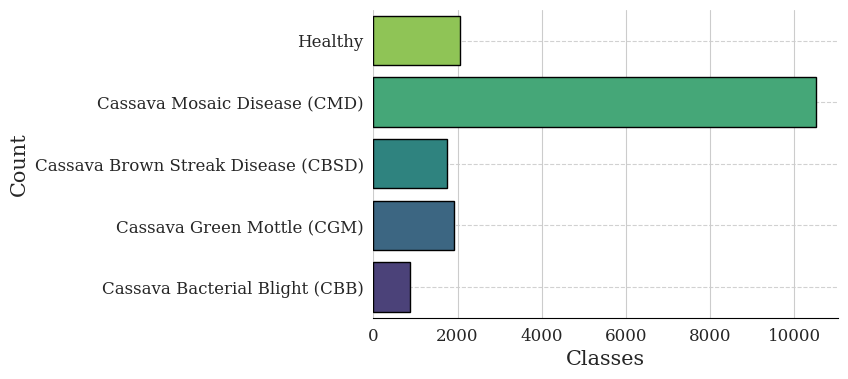

In [19]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize = (6, 4))

for i in ['top', 'right', 'left']:
    ax.spines[i].set_visible(False)
ax.spines['bottom'].set_color('black')

sns.countplot(train.label, edgecolor = 'black',
              palette = reversed(sns.color_palette("viridis", 5)))
plt.xlabel('Classes', fontfamily = 'serif', size = 15)
plt.ylabel('Count', fontfamily = 'serif', size = 15)
plt.xticks(fontfamily = 'serif', size = 12)
plt.yticks(fontfamily = 'serif', size = 12)
ax.grid(axis = 'y', linestyle = '--', alpha = 0.9)
plt.show()

### 3.1. Muestra de Imagenes

#### Plantas Healthy

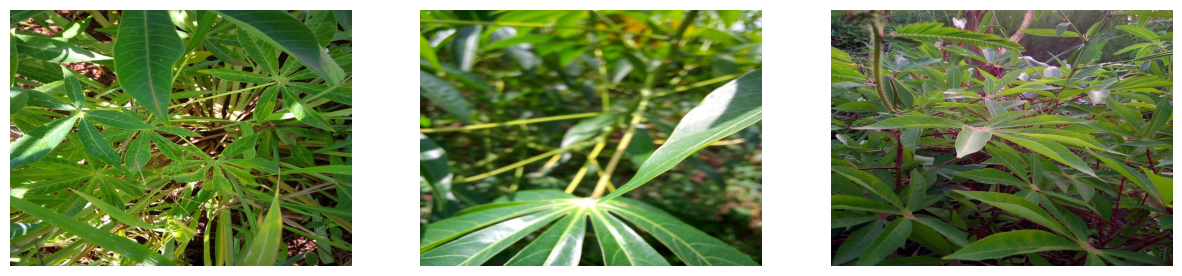

In [22]:
# Seleccionar 3 muestras de la clase "Healthy"
sample = train[train.label == "Healthy"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "train_images"

for ind, (image_id, label) in enumerate(zip(sample.image_id, sample.label)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

#### Plantas con Cassava Mosaic Disease (CMD)

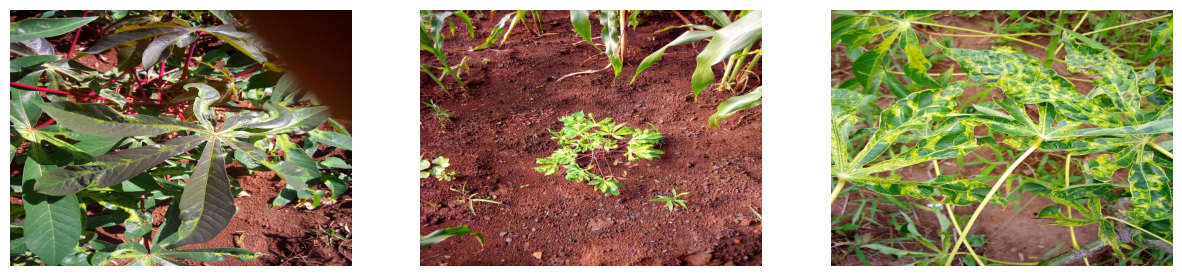

In [24]:
# Seleccionar 3 muestras de la clase "Cassava Mosaic Disease (CMD)"
sample = train[train.label == "Cassava Mosaic Disease (CMD)"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "train_images"

for ind, (image_id, label) in enumerate(zip(sample.image_id, sample.label)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

#### Plantas con Cassava Brown Streak Disease (CBSD)

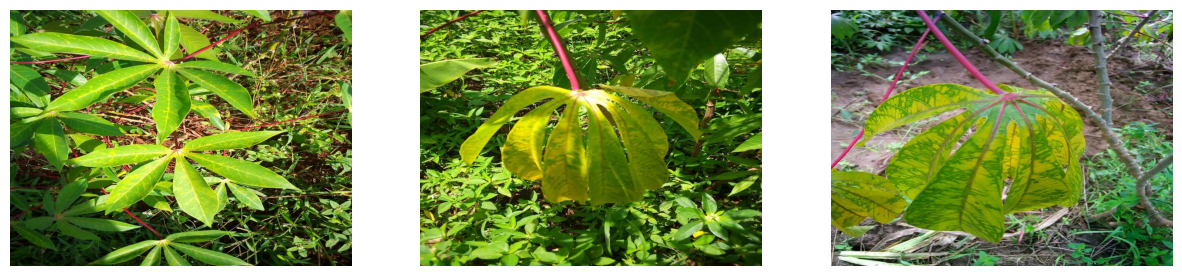

In [26]:
# Seleccionar 3 muestras de la clase "Cassava Brown Streak Disease (CBSD)"
sample = train[train.label == "Cassava Brown Streak Disease (CBSD)"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "train_images"

for ind, (image_id, label) in enumerate(zip(sample.image_id, sample.label)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

#### Plantas con Cassava Green Mottle (CGM)

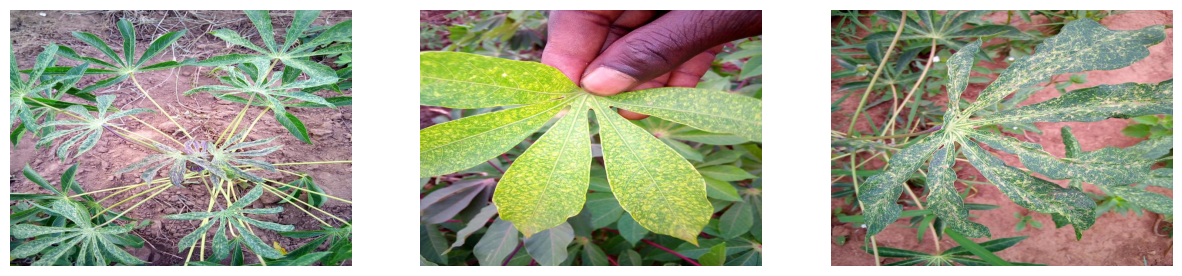

In [28]:
# Seleccionar 3 muestras de la clase "Cassava Green Mottle (CGM)"
sample = train[train.label == "Cassava Green Mottle (CGM)"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "train_images"

for ind, (image_id, label) in enumerate(zip(sample.image_id, sample.label)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

#### Plantas con Cassava Bacterial Blight (CBB)

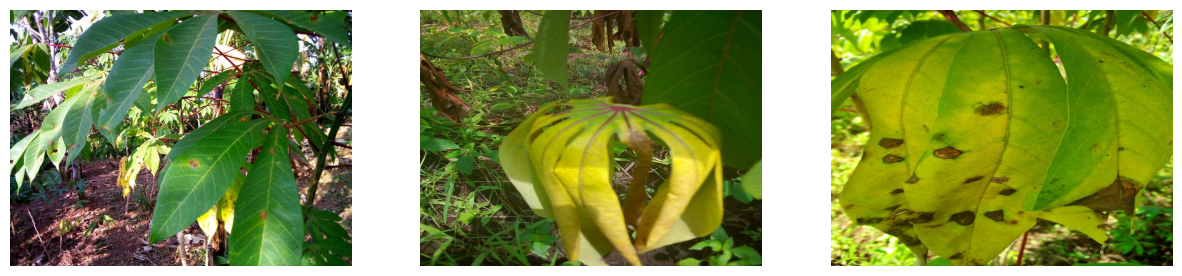

In [30]:
# Seleccionar 3 muestras de la clase "Cassava Bacterial Blight (CBB)"
sample = train[train.label == "Cassava Bacterial Blight (CBB)"].sample(3)

# Tamaño de la figura
plt.figure(figsize=(15, 5))

# Carpeta donde están las imágenes
image_folder = "train_images"

for ind, (image_id, label) in enumerate(zip(sample.image_id, sample.label)):
    plt.subplot(1, 3, ind + 1)

    # Construir la ruta completa de la imagen
    image_path = os.path.join(image_folder, image_id)

    # Cargar la imagen correctamente
    img = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if img is None:
        print(f"Error al cargar la imagen: {image_path}")
        continue

    # Convertir la imagen de BGR a RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")

plt.show()

Obtener el tamaño de las imágenes

In [32]:
# Definir la carpeta con las imágenes
image_folder = "train_images"

# Función para obtener el tamaño de una imagen
def get_image_size(image_path):
    try:
        with Image.open(image_path) as img:
            return img.size  # Devuelve (ancho, alto)
    except Exception as e:
        print(f"Error con la imagen {image_path}: {e}")
        return None, None

# Obtener el tamaño de cada imagen y agregarlo al DataFrame
widths = []
heights = []

for img_name in train["image_id"]:  # Asegúrate de que la columna se llama "image_name"
    img_path = os.path.join(image_folder, img_name)
    width, height = get_image_size(img_path)
    widths.append(width)
    heights.append(height)

train["width"] = widths
train["height"] = heights

# Mostrar las primeras filas con los nuevos datos
print(train.head())


             image_id                                label  width  height
1715   1300823152.jpg                              Healthy    800     600
11830  3116613979.jpg         Cassava Mosaic Disease (CMD)    800     600
8621   2530012971.jpg         Cassava Mosaic Disease (CMD)    800     600
3849   1686186154.jpg         Cassava Mosaic Disease (CMD)    800     600
12924  3312736716.jpg  Cassava Brown Streak Disease (CBSD)    800     600


## 4. Preparación del Modelo

In [34]:
# Main parameters
BATCH_SIZE = 8
STEPS_PER_EPOCH = len(train)*0.8 / BATCH_SIZE
VALIDATION_STEPS = len(train)*0.2 / BATCH_SIZE
EPOCHS = 20
TARGET_SIZE = 150

In [35]:
train.label = train.label.astype('str')

train_datagen = ImageDataGenerator(validation_split = 0.2,
                                     preprocessing_function = None,
                                     rotation_range = 45,
                                     zoom_range = 0.2,
                                     horizontal_flip = True,
                                     vertical_flip = True,
                                     fill_mode = 'nearest',
                                     shear_range = 0.1,
                                     height_shift_range = 0.1,
                                     width_shift_range = 0.1)

train_generator = train_datagen.flow_from_dataframe(train,
                         directory = "train_images",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")


validation_datagen = ImageDataGenerator(validation_split = 0.2)

validation_generator = validation_datagen.flow_from_dataframe(train,
                         directory = "train_images",
                         subset = "validation",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

Found 13694 validated image filenames belonging to 5 classes.
Found 3423 validated image filenames belonging to 5 classes.


Imágen Aleatoria antes de Augmentation

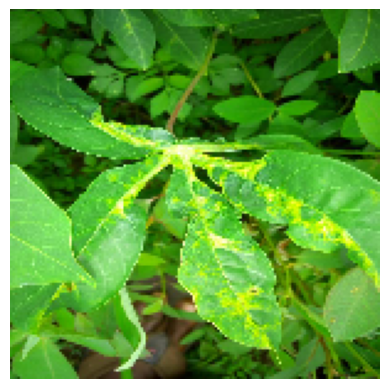

In [37]:
img_path = os.path.join("train_images", train.image_id[20])
img = image.load_img(img_path, target_size = (TARGET_SIZE, TARGET_SIZE))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis = 0)
img_tensor /= 255.

plt.imshow(img_tensor[0])
plt.axis('off')
plt.show()

Found 1 validated image filenames belonging to 1 classes.


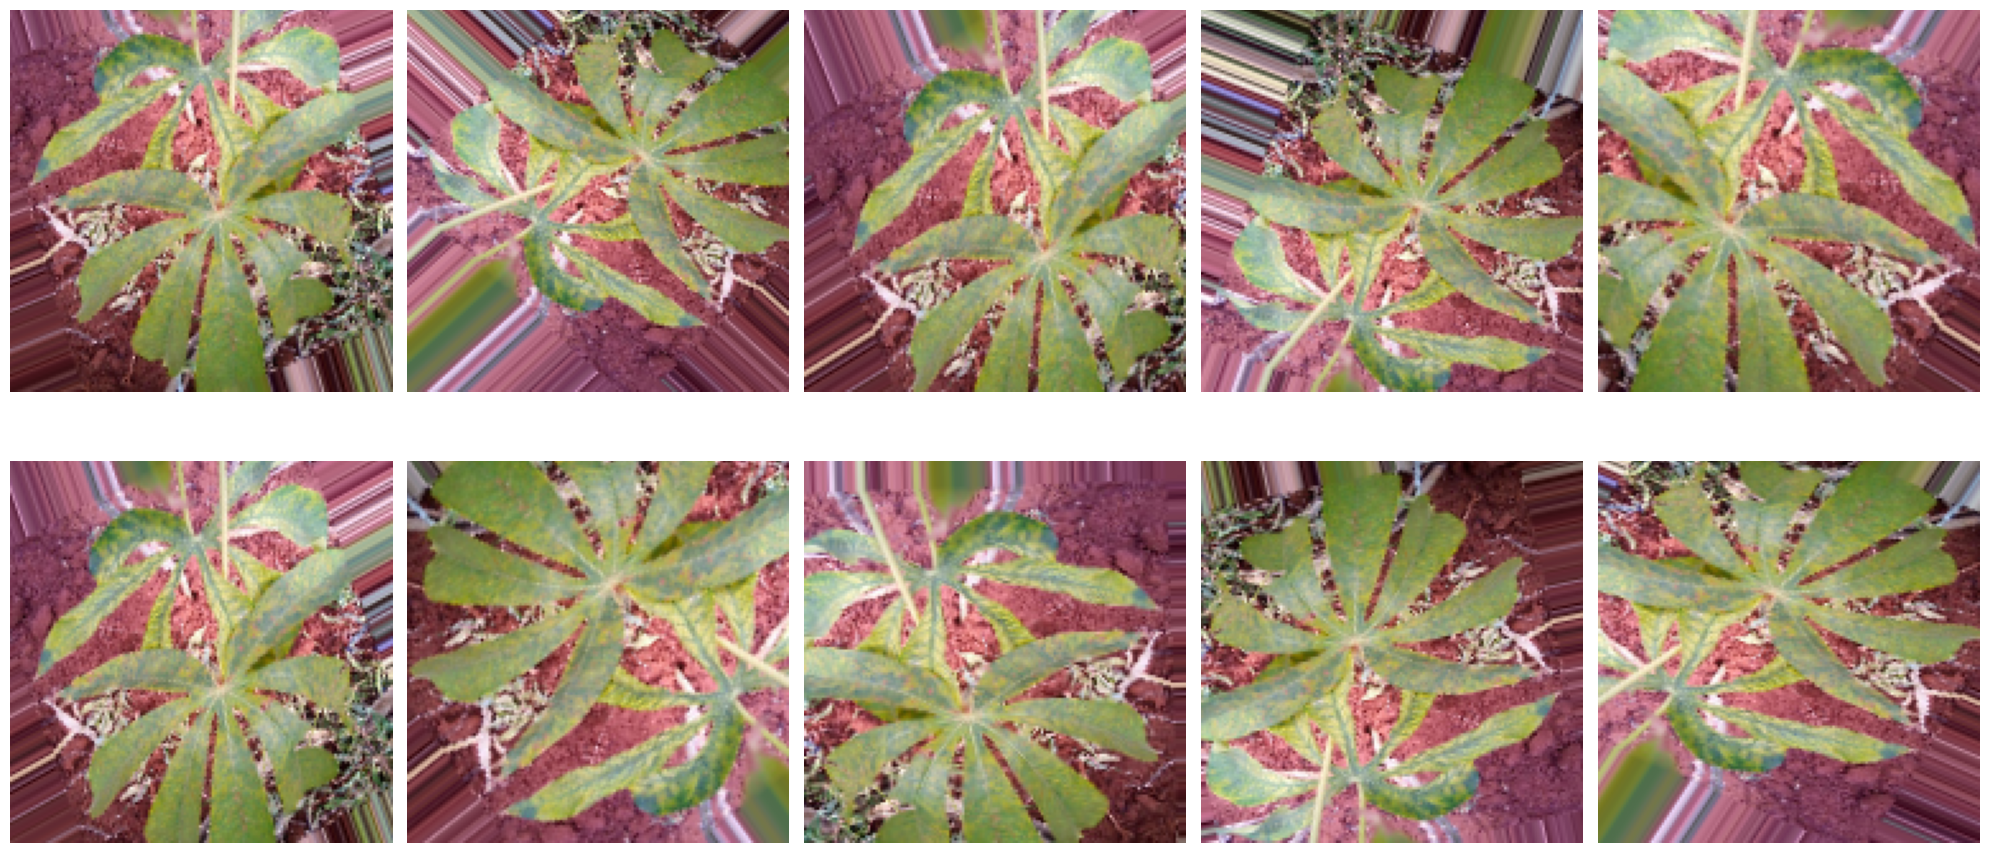

In [38]:
generator = train_datagen.flow_from_dataframe(train.iloc[20:21],
                         directory = "train_images",
                         x_col = "image_id",
                         y_col = "label",
                         target_size = (TARGET_SIZE, TARGET_SIZE),
                         batch_size = BATCH_SIZE,
                         class_mode = "categorical")

aug_images = [generator[0][0][0]/255 for i in range(10)]
fig, axes = plt.subplots(2, 5, figsize = (20, 10))
axes = axes.flatten()
for img, ax in zip(aug_images, axes):
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Construcción del Modelo

In [40]:
ccc

NameError: name 'ccc' is not defined

### 5.1. Clasificador

In [52]:
# Arquitectura del modelo CNN
model = models.Sequential()

# Capa 1: Convolucional y MaxPooling
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 2: Convolucional y MaxPooling
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 3: Convolucional y MaxPooling
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Capa 4: Convolucional y MaxPooling
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2, 2))

# Aplanamiento de la capa convolucional
model.add(layers.Flatten())

# Clasificador
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))  # Dropout para evitar el overfitting

# Capa de salida
model.add(layers.Dense(5, activation='softmax'))  

### 5.2. Compilación del modelo

In [56]:
model.compile(
    loss='categorical_crossentropy',  # Cambiado a 'categorical_crossentropy' para múltiples clases
    optimizer='adam',
    metrics=['accuracy']
)

In [58]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,456,581 (13.19 MB)

 Trainable params: 3,455,877 (13.18 MB)

 Non-trainable params: 704 (2.75 KB)

## 6. Ejecución del modelo

In [61]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,  # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore the model weights from the epoch with the best value of the monitored quantity
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,  # Reduce learning rate by a factor of 0.2
    patience=3,  # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-5  # Minimum learning rate
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

Epoch 1/5


### 6.1. Resultados del Modelo

In [ ]:
# Acceder a los datos de pérdida y precisión
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [ ]:
epochs = [1, 2, 3, 4, 5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)